# 🎯 PSM 0-1 独立练习：电信客户续约折扣评估

## 📋 业务背景

某电信公司推出了一项「**续约折扣**」政策：对部分月租用户提供 20% 折扣，鼓励他们签长期合约。

**老板的问题**："这个折扣到底降低了多少流失率？"

**难点**：享受折扣的用户本来就是"更忠诚"的用户（tenure 更长、月消费更高），直接比较会产生 **选择偏差 (Selection Bias)**。

**你的任务**：使用 **PSM (倾向性得分匹配)** 消除选择偏差，估计折扣的真实因果效应。

---

## 🧭 SOP 概览

| Step | 内容 | 你要交付的 |
| :--- | :--- | :--- |
| 0 | 函数加油站 | 阅读核心函数 |
| 1 | 数据加载 & EDA | 直接运行 |
| 2 | 业务问题定义 | 回答思考题 |
| 3 | 计算 Propensity Score | ⭐ 手写代码 |
| 4 | PSM 匹配 | ⭐ 手写代码 |
| 5 | 平衡性检验 | ⭐ SMD + Love Plot |
| 6 | 计算 ATE (PSM + IPW) | ⭐ 两种方法 |
| 7 | 敏感性分析 + 汇报 | 业务结论 |

📚 **速查手册**: [15b_psm_ipw.md](http://127.0.0.1:8000/15b_psm_ipw.html)

---

## Step 0: 函数加油站 (Function Cheat Sheet)

| 函数 | 大白话 | 常用参数 | SQL 类比 |
| :--- | :--- | :--- | :--- |
| `LogisticRegression().fit(X, y)` | 训练一个"概率分类器" | `max_iter=1000` | 无直接类比 |
| `.predict_proba(X)[:, 1]` | 预测"属于 class=1 的概率" | — | 无直接类比 |
| `NearestNeighbors(n_neighbors=1)` | 找最近的邻居 | `metric='euclidean'` | 无直接类比 |
| `.kneighbors(X)` | 返回距离和索引 | — | 无直接类比 |
| `sns.kdeplot(data, fill=True)` | 画密度曲线 | `label=`, `fill=` | 无直接类比 |
| `scipy.stats.ttest_ind(a, b)` | 独立样本 T 检验 | — | 无直接类比 |
| `smf.wls('Y ~ T', weights=w)` | 加权最小二乘回归 | `weights=` | `SELECT ... (加权)` |
| `np.where(cond, a, b)` | 条件赋值 | — | `CASE WHEN ... THEN ... ELSE` |
| `df.clip(lower, upper)` | 裁剪极端值 | `lower=`, `upper=` | `LEAST(GREATEST(x, lo), hi)` |

---

## Step 1: 数据加载 & EDA (直接运行)

In [1]:
# ===== Step 1: 数据加载 (已预写好，直接运行) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Kaggle 数据下载 (如果已有则跳过)
import os
DATA_DIR = './data'
DATA_FILE = os.path.join(DATA_DIR, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

if not os.path.exists(DATA_FILE):
    os.makedirs(DATA_DIR, exist_ok=True)
    !kaggle datasets download blastchar/telco-customer-churn --path {DATA_DIR} --unzip

df_raw = pd.read_csv(DATA_FILE)
print(f'✅ 数据加载完成: {df_raw.shape[0]} 行 × {df_raw.shape[1]} 列')
df_raw.head()

✅ 数据加载完成: 7043 行 × 21 列


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# ===== 数据预处理 (已预写好) =====
df = df_raw.copy()

# 清洗 TotalCharges (有空字符串)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# 构造 Treatment 变量:
# is_treated = 1: 签了长期合约 (One year / Two year) → 视为"享受了续约折扣"
# is_treated = 0: 月租用户 (Month-to-month) → 对照组
CONTRACT_LONG = ['One year', 'Two year']
df['is_treated'] = df['Contract'].isin(CONTRACT_LONG).astype(int)

# 构造 Outcome 变量:
df['is_churn'] = (df['Churn'] == 'Yes').astype(int)

# 选择混杂变量 (Confounders)
# 这些变量同时影响"是否签长期合约"和"是否流失"
CONFOUNDERS = ['tenure', 'MonthlyCharges', 'TotalCharges', 
               'SeniorCitizen', 'Partner', 'Dependents',
               'OnlineSecurity', 'TechSupport', 'StreamingTV']

# 编码分类变量
for col in ['Partner', 'Dependents', 'OnlineSecurity', 'TechSupport', 'StreamingTV']:
    df[col] = (df[col] == 'Yes').astype(int)

print(f'\n📊 Treatment/Control 分布:')
print(df['is_treated'].value_counts().rename({0: 'Control (月租)', 1: 'Treated (长期合约)'}))
print(f'\n📊 流失率对比:')
print(df.groupby('is_treated')['churn'].mean().rename({0: 'Control 流失率', 1: 'Treated 流失率'}))
print(f'\n⚠️ Naive 差异 = {df[df["is_treated"]==1]["churn"].mean() - df[df["is_treated"]==0]["churn"].mean():.4f}')
print('    (但这个差异包含选择偏差! 长期合约用户本来就更忠诚)')


📊 Treatment/Control 分布:
is_treated
Control (月租)      3875
Treated (长期合约)    3157
Name: count, dtype: int64

📊 流失率对比:
is_treated
Control 流失率    0.427097
Treated 流失率    0.067786
Name: churn, dtype: float64

⚠️ Naive 差异 = -0.3593
    (但这个差异包含选择偏差! 长期合约用户本来就更忠诚)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,is_treated,churn
0,7590-VHVEG,Female,0,1,0,1,No,No phone service,DSL,0,...,0,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0
1,5575-GNVDE,Male,0,0,0,34,Yes,No,DSL,1,...,0,No,One year,No,Mailed check,56.95,1889.50,No,1,0
2,3668-QPYBK,Male,0,0,0,2,Yes,No,DSL,1,...,0,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,1
3,7795-CFOCW,Male,0,0,0,45,No,No phone service,DSL,1,...,0,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1,0
4,9237-HQITU,Female,0,0,0,2,Yes,No,Fiber optic,0,...,0,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,1


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.describe(include='all').T.sort_values('unique',ascending = False)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerid,7032,7032,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paymentmethod,7032,4,Electronic check,2365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiplelines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internetservice,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinebackup,7032,3,No,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deviceprotection,7032,3,No,3094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
streamingmovies,7032,3,No,2781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract,7032,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phoneservice,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN


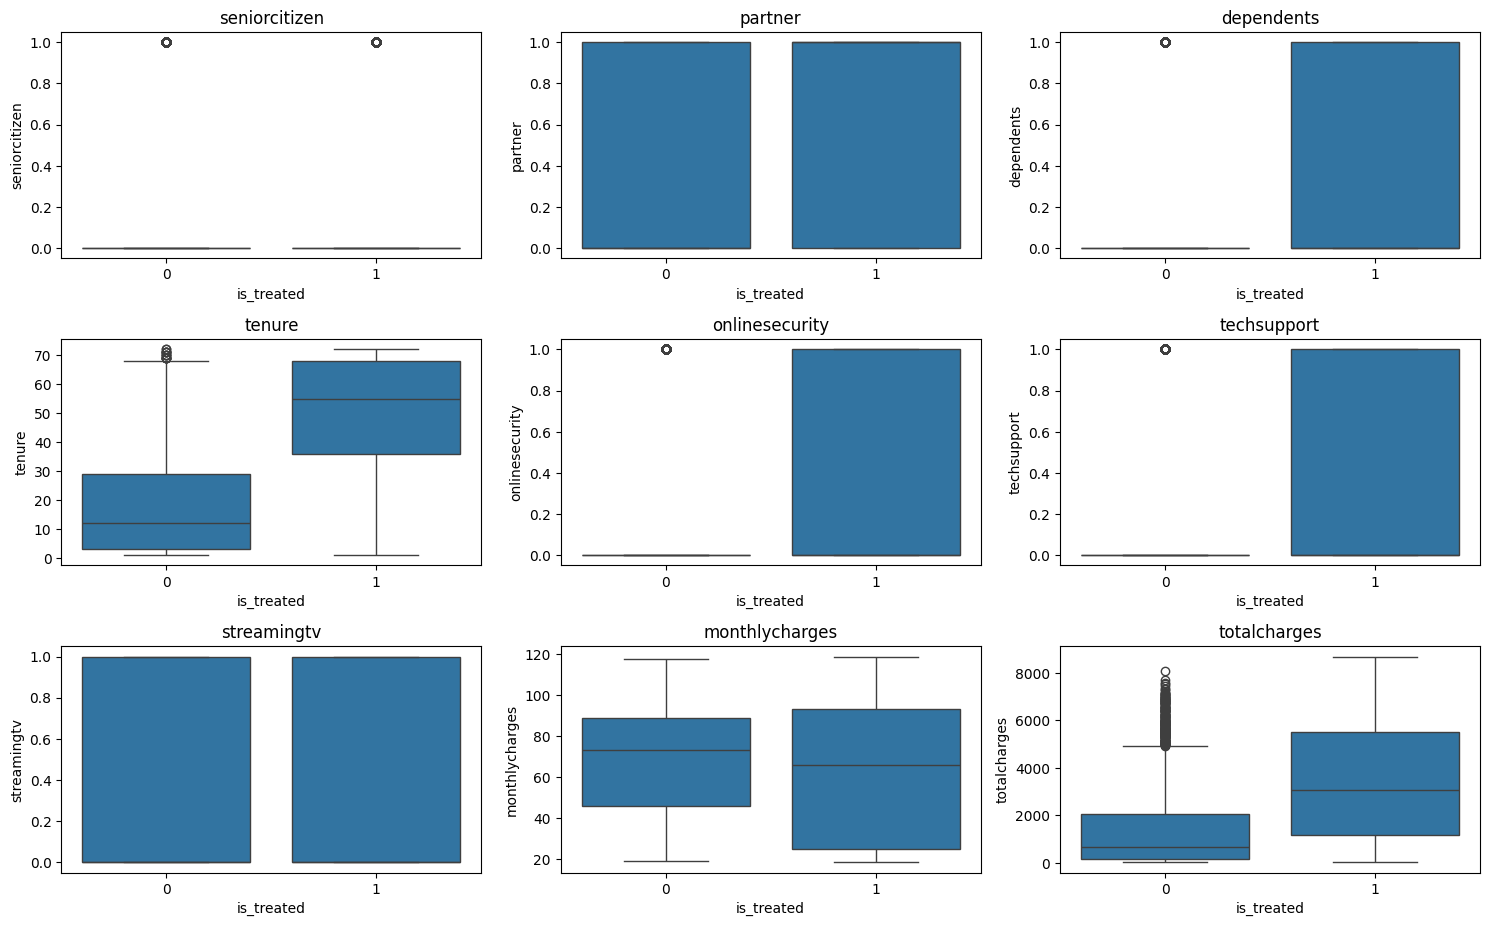


Checking for features that might perfectly predict treatment:

Dist of onlinesecurity by Treatment:
is_treated         0     1
onlinesecurity            
0               3155  1862
1                720  1295

Dist of techsupport by Treatment:
is_treated      0     1
techsupport            
0            3204  1788
1             671  1369

Dist of deviceprotection by Treatment:
is_treated              0     1
deviceprotection               
No                   2394   700
No internet service   524   996
Yes                   957  1461


In [6]:
# 0. 确保没有重复列
df = df.loc[:, ~df.columns.duplicated()]

# 1. 自动筛选所有数值列 (排除掉 label)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'is_treated' in num_cols: num_cols.remove('is_treated')

# 2. 循环画图 (subplot)
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    if i >= 12: break # Limit plots to avoid clutter
    plt.subplot(4, 3, i+1) # 假设有9个变量，3x3排列
    sns.boxplot(data=df, x='is_treated', y=col) # 对比 label=0/1 的分布差异
    plt.title(col)
plt.tight_layout()
plt.show()

# 4. Quick check for features that cause perfect separation
# Look at categorical variables that imply 'No internet service'
print("\nChecking for features that might perfectly predict treatment:")
cols_to_check = ['onlinesecurity', 'techsupport', 'deviceprotection'] 
for col in cols_to_check:
    if col in df.columns:
        print(f"\nDist of {col} by Treatment:")
        print(pd.crosstab(df[col], df['is_treated']))

In [13]:
# ===== 特征工程 & 数据清洗 (修复重复列与完美分割问题) =====

# 1. 修复重复列名问题 (df.columns.str.lower() 导致 'Churn' 和 'churn' 重名)
df = df.loc[:, ~df.columns.duplicated()]

# 2. 修复 TotalCharges 可能的非数值问题
if df['totalcharges'].dtype == 'object':
    df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
    df.dropna(subset=['totalcharges'], inplace=True)

# 3. 解决 PSM 完美分割 (Perfect Separation) 问题
# 'No internet service' 意味着 is_treated=0，这会导致倾向性得分极化
cols_to_fix = ['onlinesecurity', 'onlinebackup', 'deviceprotection', 
               'techsupport', 'streamingtv', 'streamingmovies']
for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].replace('No internet service', 'No')

# 4. 提取特征列，排除 ID 和目标变量
# ⚠️ 关键修正：必须移除 'internetservice'，因为它是定义 Treatment 的核心变量。
features = df.drop(columns=["customerid", "is_treated", "churn", "internetservice"], errors="ignore")

# 5. 对分类变量进行 One-Hot Encoding
ps_df = pd.get_dummies(features, drop_first=True)

# 6. 检查是否存在仍然完美预测的特征 (Correlation with is_treated)
# 计算 ps_df 中所有列与 is_treated 的相关性
correlations = ps_df.corrwith(df['is_treated']).sort_values(ascending=False)
print("Top 5 Positive Correlations:\n", correlations.head(5))
print("Top 5 Negative Correlations:\n", correlations.tail(5))

# 7. 查看编码后的特征概览
ps_df.describe(include='all').T.sort_values('unique', ascending=False)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender_Male,7032,2,True,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phoneservice_Yes,7032,2,True,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiplelines_No phone service,7032,2,False,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiplelines_Yes,7032,2,False,4065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internetservice_Fiber optic,7032,2,False,3936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internetservice_No,7032,2,False,5512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onlinebackup_Yes,7032,2,False,4607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deviceprotection_Yes,7032,2,False,4614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
streamingmovies_Yes,7032,2,False,4301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_One year,7032,2,False,5560,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Step 2: 业务问题定义

### 💭 思考题 (先想 3 分钟再往下看)

1. **Treatment 是什么？Control 是什么？**  
   → 提示: 签长期合约 vs 月租

2. **Outcome 是什么？**  
   → 提示: 流失了没有 (`churn`)

3. **为什么不能直接比较两组的流失率？**  
   → 提示: 什么样的人更可能签长期合约？(tenure 长? 消费高? 有家庭?)

4. **Confounders (混杂变量) 至少有哪些？**  
   → 提示: 哪些变量同时影响"签合约"和"流失"？

5. **PSM 的核心思路是什么？**  
   → 提示: 给每个 Treated 用户找一个"像双胞胎"的 Control 用户

### 📝 你的答案 (在下面的 Cell 里写)

*在这里写下你的答案...*

1. Treatment: ...
2. Outcome: ...
3. 不能直接比因为: ...
4. Confounders: ...
5. PSM 核心思路: ...

---

## Step 3: 计算 Propensity Score ⭐

### 📋 你需要做的:

1. 用 `LogisticRegression` 拟合 `is_treated ~ confounders`
2. 用 `.predict_proba()` 计算每个用户的 Propensity Score (PS)
3. 把 PS 存入 `df['ps_score']`
4. 画 PS 分布图 (KDE): Treated vs Control
5. 检查 Common Support: 两组分布是否有足够重叠？

### 💡 提示:
```python
# 速查手册 3.2: LogisticRegression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)
df['ps_score'] = lr.predict_proba(X)[:, 1]
```

### 🎯 期望结果:
- PS 分布图: 两组有一定重叠区域 (Common Support)
- 如果几乎不重叠 → 需要 Trimming

<Axes: >

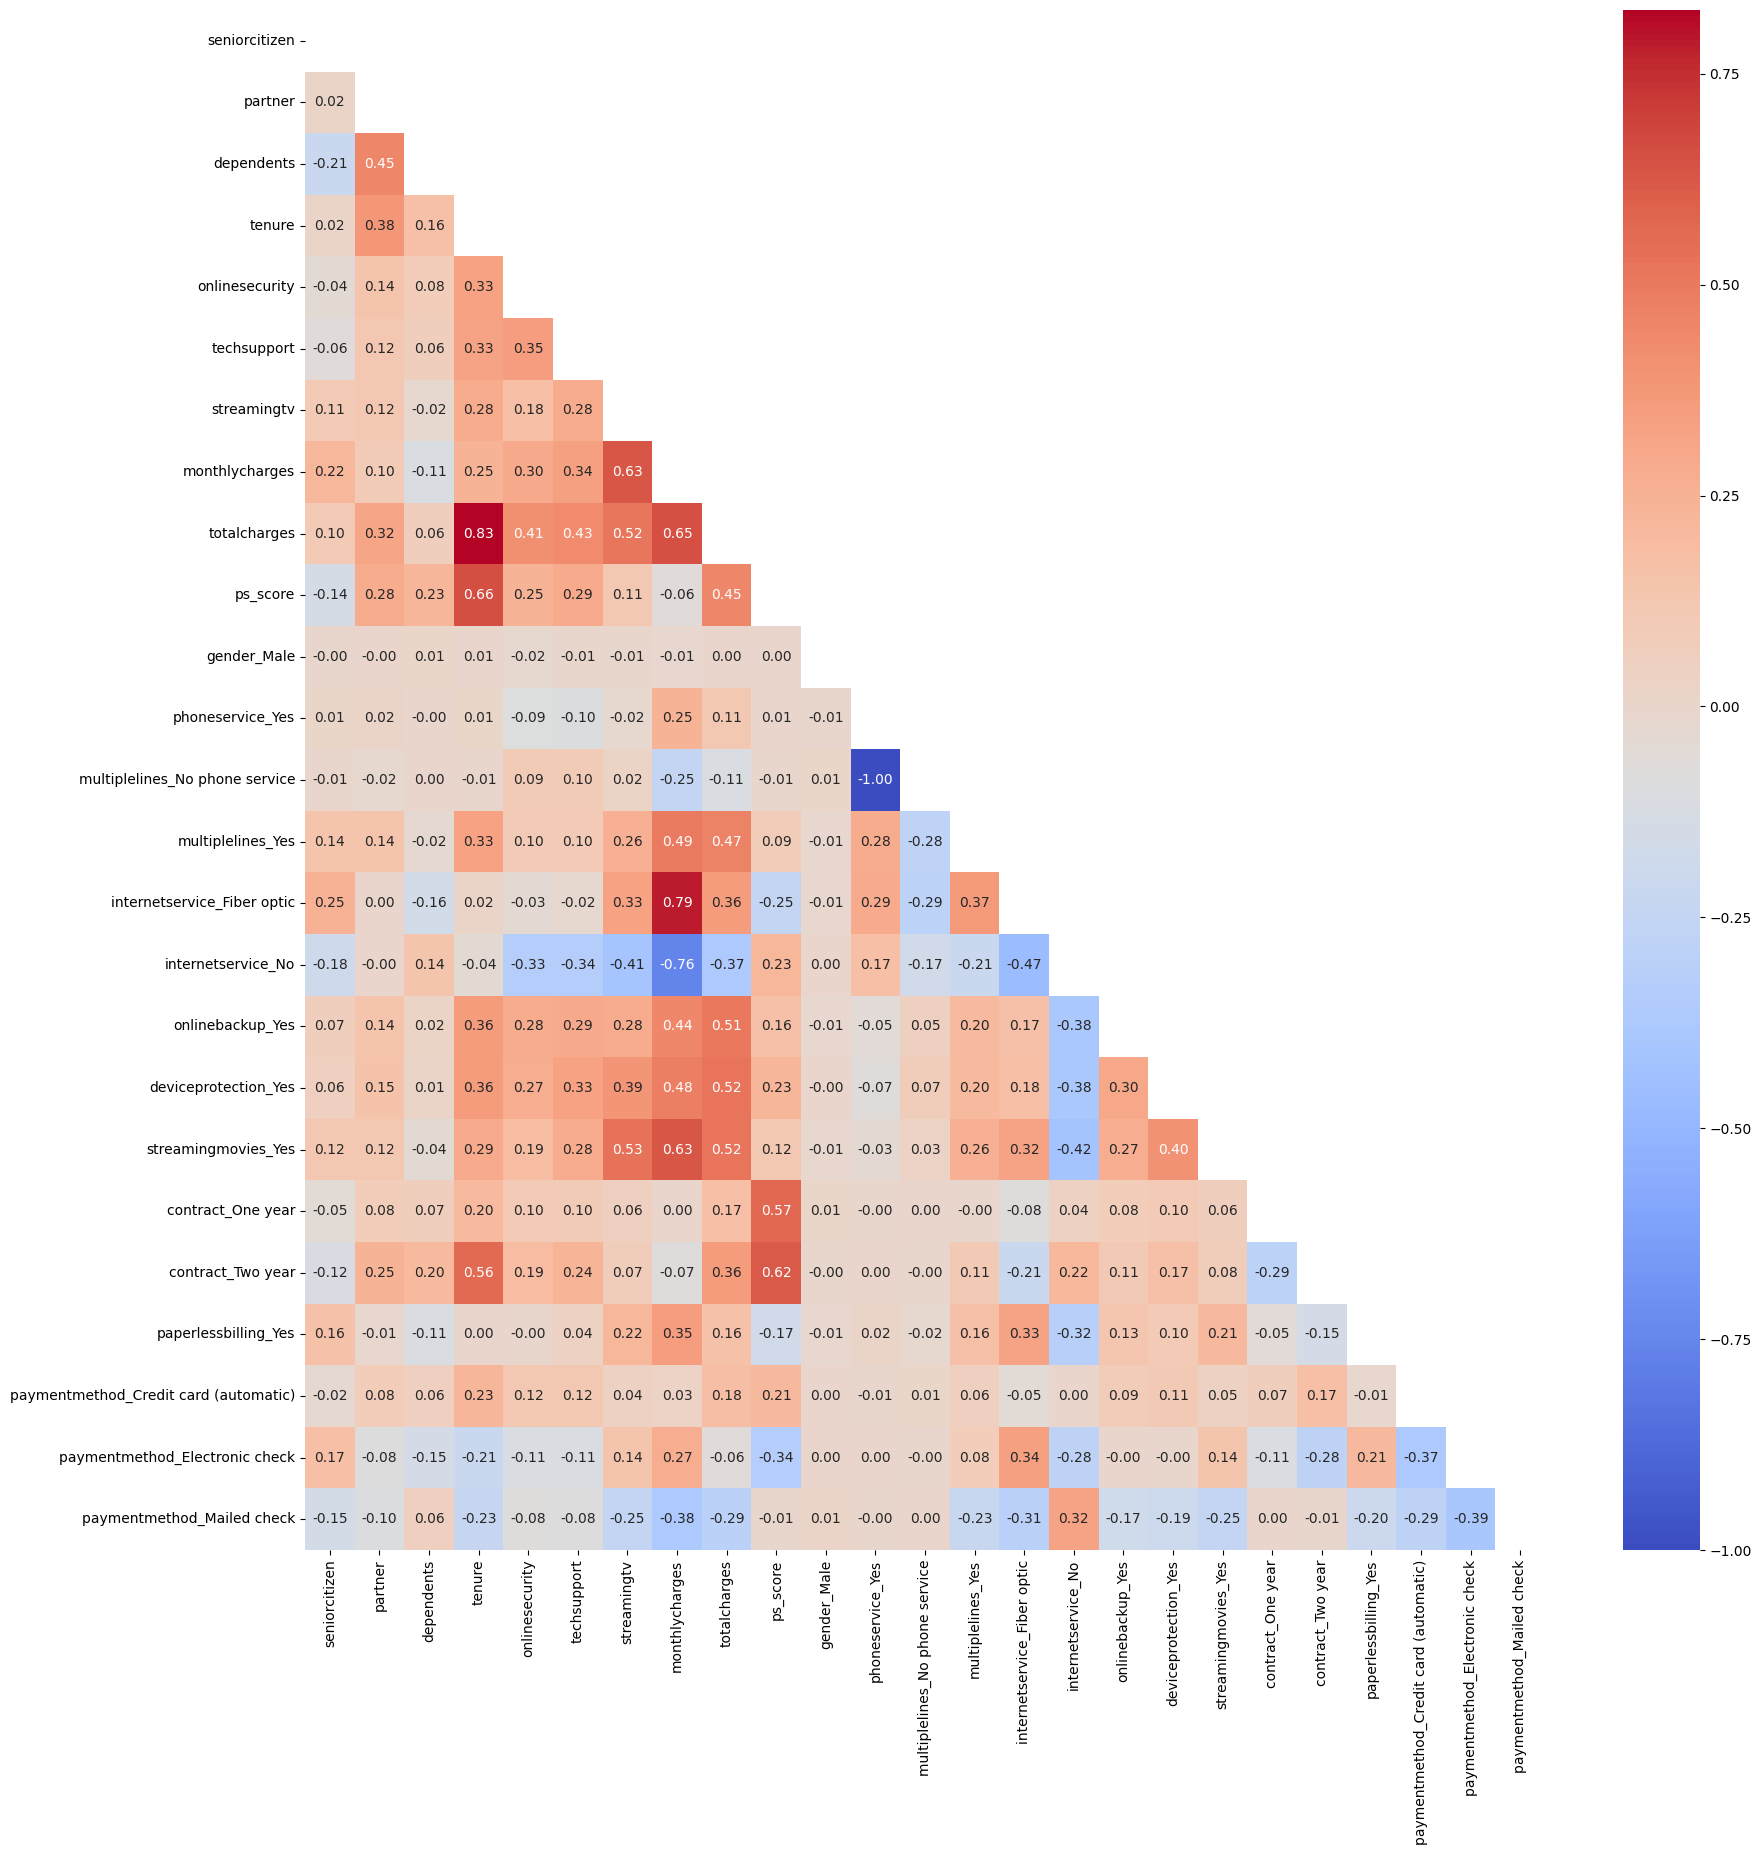

In [14]:
# df_treated = df[df['is_treated'] == 1]
# 相关性：treated组内churn的相关性表现是什么？我们要基于哪些变量构造ps_score？
corr = ps_df.corr(numeric_only=True)
plt.figure(figsize=(20,20))
# 初步结论:streamingTV monthlycharges较高相关性
# mask=np.triu(...) 用于遮挡上半三角，看起来更 Senior
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', 
            mask=np.triu(np.ones_like(corr, dtype=bool)))

In [9]:
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
x = ps_df
y = df['is_treated']

model.fit(x,y)

df['ps_score'] = model.predict_proba(x)[:,1]

treated_df = df[df['is_treated'] == 1]
control_df = df[df['is_treated'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['ps_score']])
distances,indices = nn.kneighbors(treated_df[['ps_score']])

matched_contrl = control_df.iloc[indices.flatten()]

matched_contrl.describe(include='all')

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,is_treated,ps_score
count,3157,3157,3157.0,3157.0,3157.0,3157.0,3157,3157,3157,3157.0,...,3157.0,3157,3157,3157,3157,3.157000e+03,3.157000e+03,3157,3157.0,3157.0000
unique,1,1,NaN,NaN,NaN,NaN,1,1,1,NaN,...,NaN,1,1,1,1,NaN,NaN,1,NaN,NaN
top,2363-BJLSL,Male,NaN,NaN,NaN,NaN,Yes,No,DSL,NaN,...,NaN,Yes,Month-to-month,Yes,Bank transfer (automatic),NaN,NaN,No,NaN,NaN
freq,3157,3157,NaN,NaN,NaN,NaN,3157,3157,3157,NaN,...,NaN,3157,3157,3157,3157,NaN,NaN,3157,NaN,NaN
mean,NaN,NaN,0.0,0.0,0.0,62.0,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,8.040000e+01,4.981150e+03,NaN,0.0,0.2869
std,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,1.421311e-14,9.096388e-13,NaN,0.0,0.0000
min,NaN,NaN,0.0,0.0,0.0,62.0,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,8.040000e+01,4.981150e+03,NaN,0.0,0.2869
25%,NaN,NaN,0.0,0.0,0.0,62.0,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,8.040000e+01,4.981150e+03,NaN,0.0,0.2869
50%,NaN,NaN,0.0,0.0,0.0,62.0,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,8.040000e+01,4.981150e+03,NaN,0.0,0.2869
75%,NaN,NaN,0.0,0.0,0.0,62.0,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,8.040000e+01,4.981150e+03,NaN,0.0,0.2869


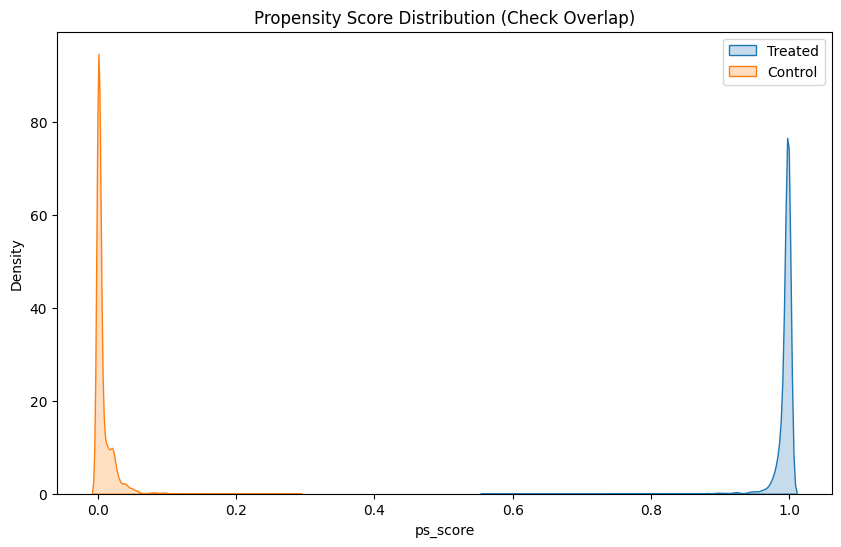

In [10]:
# 1. 绘制 PS 分布图 (必须！)
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(treated_df['ps_score'], label='Treated', fill=True)
sns.kdeplot(control_df['ps_score'], label='Control', fill=True)
plt.title('Propensity Score Distribution (Check Overlap)')
plt.legend()
plt.show()

In [11]:
# 只保留 Common Support 区域内的样本
min_ps = control_df['ps_score'].min()
max_ps = control_df['ps_score'].max()

df_trimmed = df[
    (df['ps_score'] >= min_ps) & 
    (df['ps_score'] <= max_ps)
]
print(f"Trimmed: {len(df)} -> {len(df_trimmed)} samples")

# 在截断后的数据上重新跑回归
# model_trimmed = smf.ols('outcome ~ is_treated + confounder1 + confounder2', data=df_trimmed).fit()

Trimmed: 7032 -> 3875 samples


In [15]:
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

treated_df = df_trimmed[df_trimmed['is_treated'] == 1]
control_df = df_trimmed[df_trimmed['is_treated'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['ps_score']])
distances,indices = nn.kneighbors(treated_df[['ps_score']])

matched_contrl = control_df.iloc[indices.flatten()]

matched_contrl.describe(include='all')

ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by NearestNeighbors.

In [ ]:
# 1. 绘制 PS 分布图 (必须！)
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(treated_df['ps_score'], label='Treated', fill=True)
sns.kdeplot(control_df['ps_score'], label='Control', fill=True)
plt.title('Propensity Score Distribution (Check Overlap)')
plt.legend()
plt.show()

In [ ]:
# ✍️ 你的代码: 计算 Propensity Score
# [YOUR CODE HERE]


In [ ]:
# ✍️ 你的代码: 画 PS 分布图 (KDE)
# 提示: sns.kdeplot() + 两组分开画 + plt.legend()
# [YOUR CODE HERE]


In [ ]:
# ✍️ 你的代码: Common Support 检查 & Trimming (如需要)
# 提示: 速查手册 3.3 - Trimming 截断法
# 1. 找到两组 PS 的重叠区间
# 2. 只保留在重叠区间内的样本
# 3. 打印截断前后的样本量
# [YOUR CODE HERE]


---

## Step 4: PSM 匹配 ⭐

### 📋 你需要做的:

1. 用 `NearestNeighbors` 对每个 Treated 找 1 个最近的 Control
2. 获取匹配后的 Control 子集
3. 检查是否有 Control 用户被重复匹配
4. 可视化匹配后的 PS 分布

### 💡 提示:
```python
# 速查手册 3.2: NearestNeighbors
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['ps_score']])
distances, indices = nn.kneighbors(treated[['ps_score']])
matched_control = control.iloc[indices.flatten()]
```

### 🎯 期望结果:
- `matched_control` 的样本量 = `treated` 的样本量
- 匹配后 PS 分布更接近

In [ ]:
# ✍️ 你的代码: PSM 1:1 匹配
# [YOUR CODE HERE]


In [ ]:
# ✍️ 你的代码: 检查重复匹配 + 匹配后 PS 分布
# 提示:
# 1. matched_control['customerID'].value_counts().head() 看有没有用户被匹配多次
# 2. 再画一次 KDE 对比匹配前 vs 匹配后
# [YOUR CODE HERE]


---

## Step 5: 平衡性检验 (Balance Check) ⭐

### 📋 你需要做的:

匹配后，必须验证 Treated 和 Control 在**每个混杂变量**上已经"齐平"。

1. 计算 **SMD (Standardized Mean Difference)**:  
   `SMD = |mean_treated - mean_control| / sqrt((var_t + var_c) / 2)`
2. SMD < 0.1 = 平衡 ✅, SMD > 0.25 = 严重不平衡 ❌
3. 画 Love Plot: 匹配前 vs 匹配后的 SMD 对比

### 💡 提示:
```python
# 计算单个变量的 SMD
def calc_smd(treated_vals, control_vals):
    diff = abs(treated_vals.mean() - control_vals.mean())
    pooled_std = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
    return diff / pooled_std if pooled_std > 0 else 0
```

### 🎯 期望结果:
- 匹配后所有 SMD < 0.1 (或至少 < 0.25)
- Love Plot 显示匹配后 SMD 大幅缩小

In [ ]:
# ✍️ 你的代码: 计算匹配前后的 SMD
# 提示: 遍历 CONFOUNDERS 列表，分别计算匹配前后的 SMD
# [YOUR CODE HERE]


In [ ]:
# ✍️ 你的代码: 画 Love Plot (匹配前后 SMD 对比)
# 提示:
# plt.barh() 或 plt.scatter()
# x 轴: SMD, y 轴: 变量名
# 两组颜色: 匹配前 (红) vs 匹配后 (蓝)
# 加一条 x=0.1 的虚线标记问题
# [YOUR CODE HERE]


---

## Step 6: 计算 ATE ⭐ (两种方法)

### 方法 A: PSM 匹配后直接比较

最简单的方式：匹配后 Treated 和 Control 的 Outcome 均值差。

```
ATE_psm = mean(churn_treated) - mean(churn_matched_control)
```

### 方法 B: IPW (逆概率加权)

不丢弃任何样本，而是用权重"重新平衡"。

```
Weight_treated = 1 / PS
Weight_control = 1 / (1 - PS)
```

### 💡 提示:
- 速查手册 4.4: IPW 代码模板
- 权重截断 `clip(upper=10)` 防止方差爆炸
- 用 `smf.wls()` 获得 P 值

### 🎯 期望结果:
- PSM ATE 和 IPW ATE 应该**方向一致** (都为负 = 折扣降低了流失)
- 如果大小接近 → 结论稳健

In [ ]:
# ✍️ 你的代码: 方法 A — PSM 匹配后直接比较
# [YOUR CODE HERE]


In [ ]:
# ✍️ 你的代码: 方法 B — IPW (逆概率加权)
# 提示: 
# 1. 计算权重: np.where(is_treated==1, 1/ps, 1/(1-ps))
# 2. 截断权重: clip(upper=10)
# 3. 用 smf.wls() 跑加权回归获取 P 值
# [YOUR CODE HERE]


In [ ]:
# ✍️ 你的代码: 对比两种方法的 ATE
# 提示: 打印一个简洁的对比表
# [YOUR CODE HERE]


---

## Step 7: 敏感性分析 + Executive Summary

### Part A: 敏感性分析 (删变量看系数偏差)

**逻辑**: 如果你删掉一个混杂变量，ATE 变化了很多 → 说明那个变量很重要。

```
bias_pct = |ATE_slim - ATE_full| / |ATE_full| * 100
```

### Part B: Executive Summary

用业务语言总结你的发现：

1. **背景**: 评估什么？对谁？
2. **方法**: PSM + IPW
3. **核心结论**: 折扣降低了 X% 的流失率
4. **稳健性**: 两种方法一致 + 敏感性分析通过
5. **建议**: 是否推广？

In [ ]:
# ✍️ 你的代码: 敏感性分析
# 提示: 速查手册 3.5 - 删变量看系数偏差
# 1. 全模型 ATE (用所有 CONFOUNDERS)
# 2. 逐个删除一个 Confounder，重跑 PSM，看 ATE 变化
# 3. 偏差 < 5% → 安全; > 10% → 该变量很关键
# [YOUR CODE HERE]


### 📝 你的 Executive Summary (在这里写)

**背景**: ...

**方法**: ...

**核心结论**: ...

**稳健性**: ...

**建议**: ...

---

## ✅ 灵魂发问 Checklist

完成后逐条自检，每项都能回答才算真正掌握：

- [ ] 我能解释 PSM 解决的是什么问题 (选择偏差)
- [ ] 我能说出 Propensity Score 的计算方法 (Logistic)
- [ ] 我能画出 PS 分布图并判断 Common Support
- [ ] 我知道 Trimming 什么时候需要做、怎么做
- [ ] 我能计算 SMD 并判断是否平衡 (< 0.1)
- [ ] 我能用两种方法计算 ATE (PSM vs IPW)
- [ ] 我能解释 IPW 的权重公式和截断的原因
- [ ] 我能做敏感性分析 (删变量看偏差)
- [ ] 我能用业务语言写 Executive Summary
- [ ] 我能解释 PSM vs SCM vs DML 的适用场景差异